## Link to Manuscript

[![arXiv](https://img.shields.io/badge/arXiv-2406.12345-b31b1b.svg)](https://arxiv.org/abs/2406.12345)
[![HAL](https://img.shields.io/badge/HAL-hal--12345678-0e71b8.svg)](https://hal.science/hal-12345678)
[![Figshare](https://img.shields.io/badge/Figshare-DOI-blue.svg)](https://doi.org/10.6084/m9.figshare.XXXXXXX)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install scikit-learn==1.5.0

In [2]:
!pip install scikeras

In [3]:
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.7 MB/s eta 0:00:00


In [ ]:
!pip install scikit-optimize tensorflow keras

In [4]:
# Import necessary libraries
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error, accuracy_score
from sklearn.ensemble import RandomForestRegressor
import itertools
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Dense, LSTM
import statsmodels.api as sm
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
from scikeras.wrappers import KerasRegressor

In [5]:
df = pd.read_csv("/content/drive/MyDrive/Datasets/Well production analysis data.csv")
df.shape

(15634, 16)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15634 entries, 0 to 15633
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   DATEPRD                   15634 non-null  object 
 1   NPD_WELL_BORE_NAME        15634 non-null  object 
 2   ON_STREAM_HRS             15349 non-null  float64
 3   AVG_DOWNHOLE_PRESSURE     8980 non-null   float64
 4   AVG_DOWNHOLE_TEMPERATURE  8980 non-null   float64
 5   AVG_DP_TUBING             8980 non-null   float64
 6   AVG_ANNULUS_PRESS         7890 non-null   float64
 7   AVG_CHOKE_SIZE_P          8919 non-null   float64
 8   AVG_WHP_P                 9155 non-null   float64
 9   AVG_WHT_P                 9146 non-null   float64
 10  DP_CHOKE_SIZE             15340 non-null  float64
 11  BORE_OIL_VOL              9161 non-null   float64
 12  BORE_GAS_VOL              9161 non-null   float64
 13  BORE_WAT_VOL              9161 non-null   float64
 14  BORE_W

In [7]:
# Filter for 'production' flow kind
production_wells = df[df['FLOW_KIND'] == 'production']

# Group by well and calculate the total production volume
well_production = production_wells.groupby('NPD_WELL_BORE_NAME')['BORE_GAS_VOL'].sum()

# Get the top 5 wells with the highest production volume
top_5_wells = well_production.nlargest(5)

# Get the names of the top 5 wells
top_5_well_names = top_5_wells.index

# Create a new DataFrame containing data for only the top 5 wells
top_5_wells_df = df[df['NPD_WELL_BORE_NAME'].isin(top_5_well_names)]

# Display the new DataFrame
display(top_5_wells_df)

,DATEPRD,NPD_WELL_BORE_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,AVG_DP_TUBING,AVG_ANNULUS_PRESS,AVG_CHOKE_SIZE_P,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,BORE_WI_VOL,FLOW_KIND
0,07-Apr-14,15/9-F-1 C,0.0,0.000,0.000,0.000,0.0,0.00000,0.000,0.00,0.000,0.0,0.0,0.0,NaN,production
1,08-Apr-14,15/9-F-1 C,0.0,NaN,NaN,NaN,0.0,1.00306,0.000,0.00,0.000,0.0,0.0,0.0,NaN,production
2,09-Apr-14,15/9-F-1 C,0.0,NaN,NaN,NaN,0.0,0.97901,0.000,0.00,0.000,0.0,0.0,0.0,NaN,production
3,10-Apr-14,15/9-F-1 C,0.0,NaN,NaN,NaN,0.0,0.54576,0.000,0.00,0.000,0.0,0.0,0.0,NaN,production
4,11-Apr-14,15/9-F-1 C,0.0,310.376,96.876,277.278,0.0,1.21599,33.098,10.48,33.072,0.0,0.0,0.0,NaN,production
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8996,13-Sep-16,15/9-F-15 D,0.0,345.907,90.034,345.907,0.0,0.99925,0.000,0.00,13.974,0.0,0.0,0.0,NaN,production
8997,14-Sep-16,15/9-F-15 D,0.0,345.907,90.034,345.907,0.0,1.04949,0.000,0.00,14.063,0.0,0.0,0.0,NaN,production
8998,15-Sep-16,15/9-F-15 D,0.0,345.907,90.034,345.907,0.0,0.97485,0.000,0.00,14.174,0.0,0.0,0.0,NaN,production
8999,16-Sep-16,15/9-F-15 D,0.0,345.907,90.034,345.907,0.0,0.96874,0.000,0.00,14.233,0.0,0.0,0.0,NaN,production


In [8]:
# Get unique well names and date ranges of data collected
top_5_well_names = df['NPD_WELL_BORE_NAME'].unique()

# Create a dictionary to store date ranges
date_ranges = {}

# Iterate through well names and get date ranges
for well_name in top_5_well_names:
    well_data = df[df['NPD_WELL_BORE_NAME'] == well_name]
    min_date = well_data['DATEPRD'].min()
    max_date = well_data['DATEPRD'].max()
    date_ranges[well_name] = (min_date, max_date)

# Print the date ranges
for well_name, date_range in date_ranges.items():
    print(f"Well: {well_name}, Date Range: {date_range[0]} to {date_range[1]}")

Well: 15/9-F-1 C, Date Range: 01-Apr-15 to 31-Oct-15
Well: 15/9-F-11, Date Range: 01-Apr-14 to 31-Oct-15
Well: 15/9-F-12, Date Range: 01-Apr-08 to 31-Oct-15
Well: 15/9-F-14, Date Range: 01-Apr-08 to 31-Oct-15
Well: 15/9-F-15 D, Date Range: 01-Apr-14 to 31-Oct-15
Well: 15/9-F-4, Date Range: 01-Apr-08 to 31-Oct-15
Well: 15/9-F-5, Date Range: 01-Apr-08 to 31-Oct-15


In [9]:
df = top_5_wells_df.copy()
df

,DATEPRD,NPD_WELL_BORE_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,AVG_DP_TUBING,AVG_ANNULUS_PRESS,AVG_CHOKE_SIZE_P,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,BORE_WI_VOL,FLOW_KIND
0,07-Apr-14,15/9-F-1 C,0.0,0.000,0.000,0.000,0.0,0.00000,0.000,0.00,0.000,0.0,0.0,0.0,NaN,production
1,08-Apr-14,15/9-F-1 C,0.0,NaN,NaN,NaN,0.0,1.00306,0.000,0.00,0.000,0.0,0.0,0.0,NaN,production
2,09-Apr-14,15/9-F-1 C,0.0,NaN,NaN,NaN,0.0,0.97901,0.000,0.00,0.000,0.0,0.0,0.0,NaN,production
3,10-Apr-14,15/9-F-1 C,0.0,NaN,NaN,NaN,0.0,0.54576,0.000,0.00,0.000,0.0,0.0,0.0,NaN,production
4,11-Apr-14,15/9-F-1 C,0.0,310.376,96.876,277.278,0.0,1.21599,33.098,10.48,33.072,0.0,0.0,0.0,NaN,production
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8996,13-Sep-16,15/9-F-15 D,0.0,345.907,90.034,345.907,0.0,0.99925,0.000,0.00,13.974,0.0,0.0,0.0,NaN,production
8997,14-Sep-16,15/9-F-15 D,0.0,345.907,90.034,345.907,0.0,1.04949,0.000,0.00,14.063,0.0,0.0,0.0,NaN,production
8998,15-Sep-16,15/9-F-15 D,0.0,345.907,90.034,345.907,0.0,0.97485,0.000,0.00,14.174,0.0,0.0,0.0,NaN,production
8999,16-Sep-16,15/9-F-15 D,0.0,345.907,90.034,345.907,0.0,0.96874,0.000,0.00,14.233,0.0,0.0,0.0,NaN,production


In [10]:
# Check flow kind
df["FLOW_KIND"].unique()

array(['production'], dtype=object)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9001 entries, 0 to 9000
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   DATEPRD                   9001 non-null   object 
 1   NPD_WELL_BORE_NAME        9001 non-null   object 
 2   ON_STREAM_HRS             9001 non-null   float64
 3   AVG_DOWNHOLE_PRESSURE     8980 non-null   float64
 4   AVG_DOWNHOLE_TEMPERATURE  8980 non-null   float64
 5   AVG_DP_TUBING             8980 non-null   float64
 6   AVG_ANNULUS_PRESS         7730 non-null   float64
 7   AVG_CHOKE_SIZE_P          8759 non-null   float64
 8   AVG_WHP_P                 8995 non-null   float64
 9   AVG_WHT_P                 8995 non-null   float64
 10  DP_CHOKE_SIZE             8995 non-null   float64
 11  BORE_OIL_VOL              9001 non-null   float64
 12  BORE_GAS_VOL              9001 non-null   float64
 13  BORE_WAT_VOL              9001 non-null   float64
 14  BORE_WI_VOL  

In [12]:
# Get percentage of missing values
df.isna().sum()/len(df)*100

,0
DATEPRD,0.000000
NPD_WELL_BORE_NAME,0.000000
ON_STREAM_HRS,0.000000
AVG_DOWNHOLE_PRESSURE,0.233307
AVG_DOWNHOLE_TEMPERATURE,0.233307
AVG_DP_TUBING,0.233307
AVG_ANNULUS_PRESS,14.120653
AVG_CHOKE_SIZE_P,2.688590
AVG_WHP_P,0.066659
AVG_WHT_P,0.066659


In [13]:
# Calculate the percentage of zero values in the 'BORE_GAS_VOL' column
percentage_zeros = (df['BORE_GAS_VOL'] == 0).sum() * 100 / len(df)

# Print the result
print(f"Percentage of zero values in BORE_GAS_VOL: {percentage_zeros:.2f}%")

Percentage of zero values in BORE_GAS_VOL: 12.43%


In [14]:
# Drop rows where 'BORE_GAS_VOL' is 0
df = df[df['BORE_GAS_VOL'] != 0]

# Reset the index
df = df.reset_index(drop=True)

# Calculate the percentage of zero values in the 'BORE_OIL_VOL' column after dropping
percentage_zeros = (df['BORE_GAS_VOL'] == 0).sum() * 100 / len(df)

# Print the result
print(f"Percentage of zero values in BORE_GAS_VOL afer dropping: {percentage_zeros:.2f}%")

Percentage of zero values in BORE_GAS_VOL afer dropping: 0.00%


In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ON_STREAM_HRS,7882.0,23.049611,3.517083,0.00000,24.000000,24.000000,24.00000,25.000
AVG_DOWNHOLE_PRESSURE,7867.0,181.571381,105.235159,0.00000,197.248500,230.205000,251.88350,314.778
AVG_DOWNHOLE_TEMPERATURE,7867.0,78.947726,45.063872,0.00000,99.378500,104.994000,106.38700,108.502
AVG_DP_TUBING,7867.0,153.896550,70.834180,0.00000,148.918500,176.185000,203.91100,259.087
AVG_ANNULUS_PRESS,6938.0,16.128899,7.668879,0.00000,12.900250,17.869000,21.66575,30.020
AVG_CHOKE_SIZE_P,7882.0,60.834594,33.810290,0.32705,33.235868,58.318905,100.00000,100.000
AVG_WHP_P,7879.0,45.588510,18.958856,0.00000,32.105000,38.591000,55.25850,120.889
AVG_WHT_P,7879.0,76.459348,17.527831,0.00000,72.689500,82.262000,88.48100,93.510
DP_CHOKE_SIZE,7879.0,16.459371,17.428416,0.00000,3.460500,9.002000,24.30250,106.035
BORE_OIL_VOL,7882.0,1268.203121,1349.522447,0.00000,270.000000,735.500000,1684.50000,5902.000


In [16]:
# Convert date column to datetimeIndex
df['DATEPRD']=pd.to_datetime(df['DATEPRD'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7882 entries, 0 to 7881
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   DATEPRD                   7882 non-null   datetime64[ns]
 1   NPD_WELL_BORE_NAME        7882 non-null   object        
 2   ON_STREAM_HRS             7882 non-null   float64       
 3   AVG_DOWNHOLE_PRESSURE     7867 non-null   float64       
 4   AVG_DOWNHOLE_TEMPERATURE  7867 non-null   float64       
 5   AVG_DP_TUBING             7867 non-null   float64       
 6   AVG_ANNULUS_PRESS         6938 non-null   float64       
 7   AVG_CHOKE_SIZE_P          7882 non-null   float64       
 8   AVG_WHP_P                 7879 non-null   float64       
 9   AVG_WHT_P                 7879 non-null   float64       
 10  DP_CHOKE_SIZE             7879 non-null   float64       
 11  BORE_OIL_VOL              7882 non-null   float64       
 12  BORE_GAS_VOL        

In [17]:
# Get top five well names
df["NPD_WELL_BORE_NAME"].unique()

array(['15/9-F-1 C', '15/9-F-11', '15/9-F-12', '15/9-F-14', '15/9-F-15 D'],
      dtype=object)

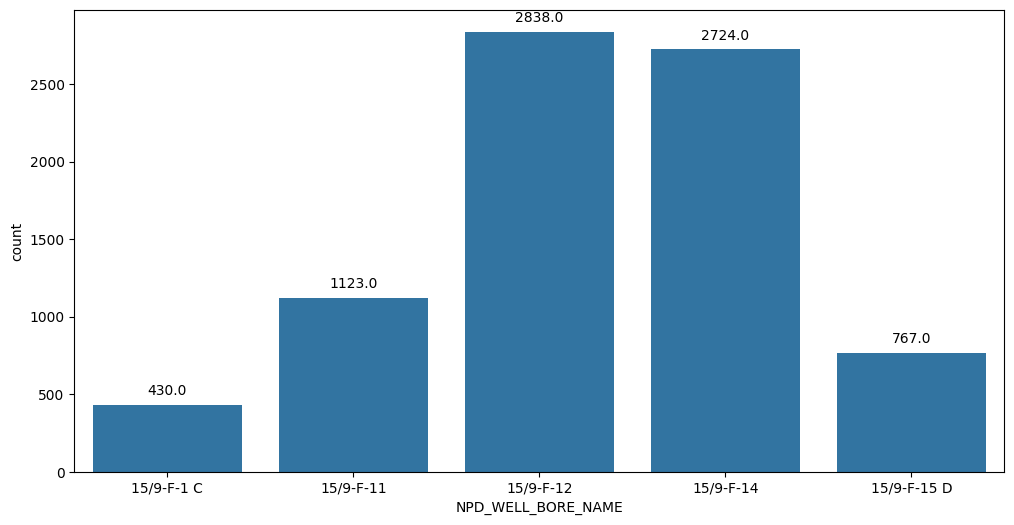

In [18]:
# Plot counts of each well
plt.figure(figsize=(12, 6))

# Create the countplot
ax = sns.countplot(x='NPD_WELL_BORE_NAME', data=df)

# Add labels to each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

# Display the plot
plt.show()

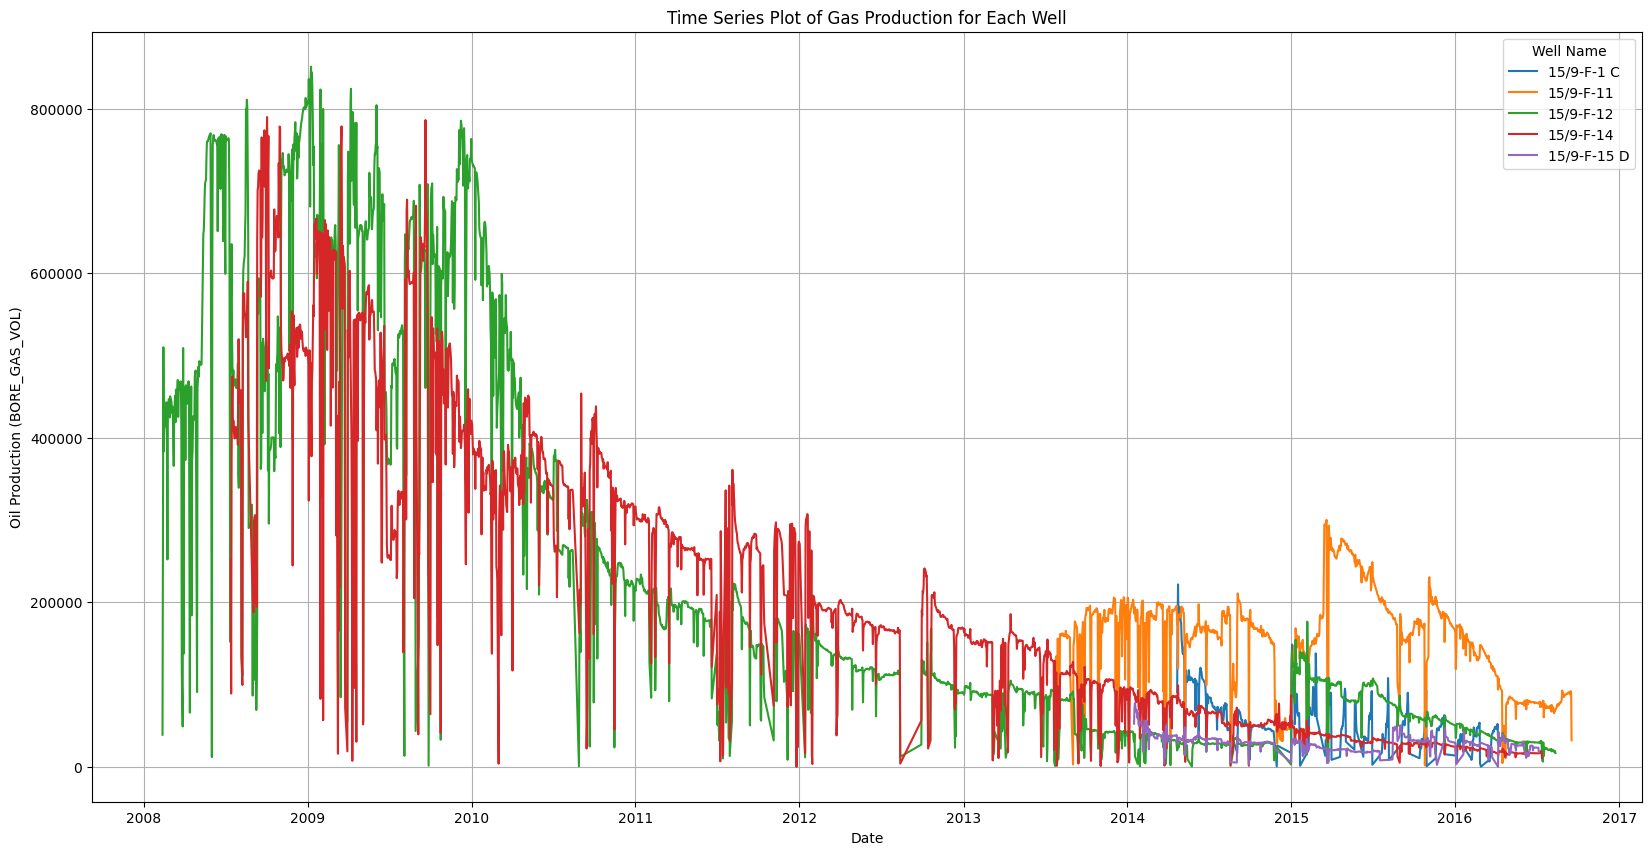

In [19]:
# Create the time series plot
plt.figure(figsize=(20, 10))
sns.lineplot(x='DATEPRD', y='BORE_GAS_VOL', hue='NPD_WELL_BORE_NAME', data=df)
plt.xlabel('Date')
plt.ylabel('Oil Production (BORE_GAS_VOL)')
plt.title('Time Series Plot of Gas Production for Each Well')
plt.grid(True)
plt.legend(title='Well Name')
plt.show()

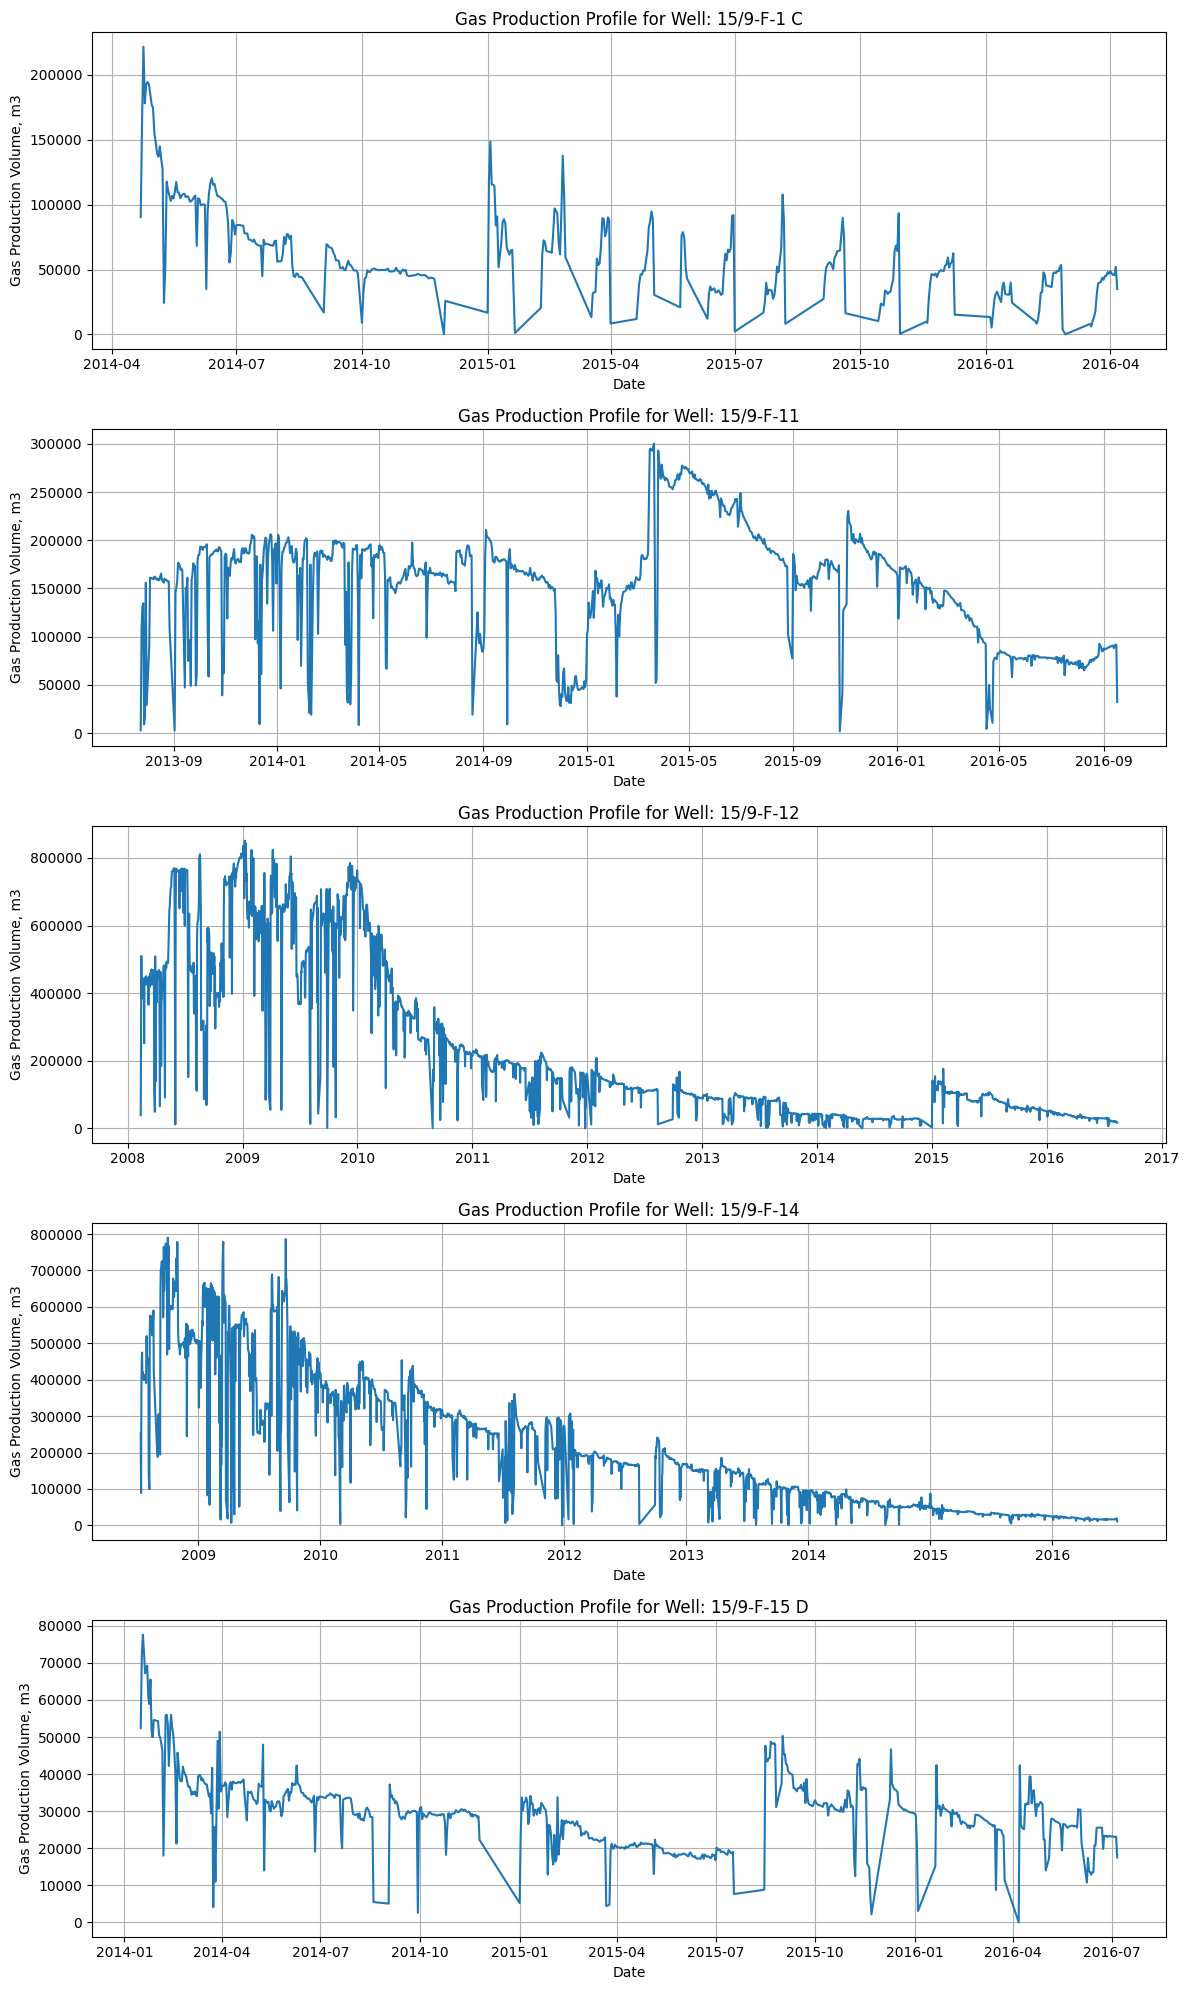

In [20]:
# Get unique well names
well_names = df['NPD_WELL_BORE_NAME'].unique()

# Create subplots
fig, axes = plt.subplots(len(well_names), 1, figsize=(12, 4 * len(well_names)))

# Iterate through well names and plot each time series
for i, well_name in enumerate(well_names):
    well_data = df[df['NPD_WELL_BORE_NAME'] == well_name]
    sns.lineplot(x='DATEPRD', y='BORE_GAS_VOL', data=well_data, ax=axes[i])
    axes[i].set_title(f'Gas Production Profile for Well: {well_name}')
    axes[i].set_ylabel('Gas Production Volume, m3')
    axes[i].set_xlabel('Date')
    axes[i].grid(True)

# Set common x-axis label
plt.xlabel('Date')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

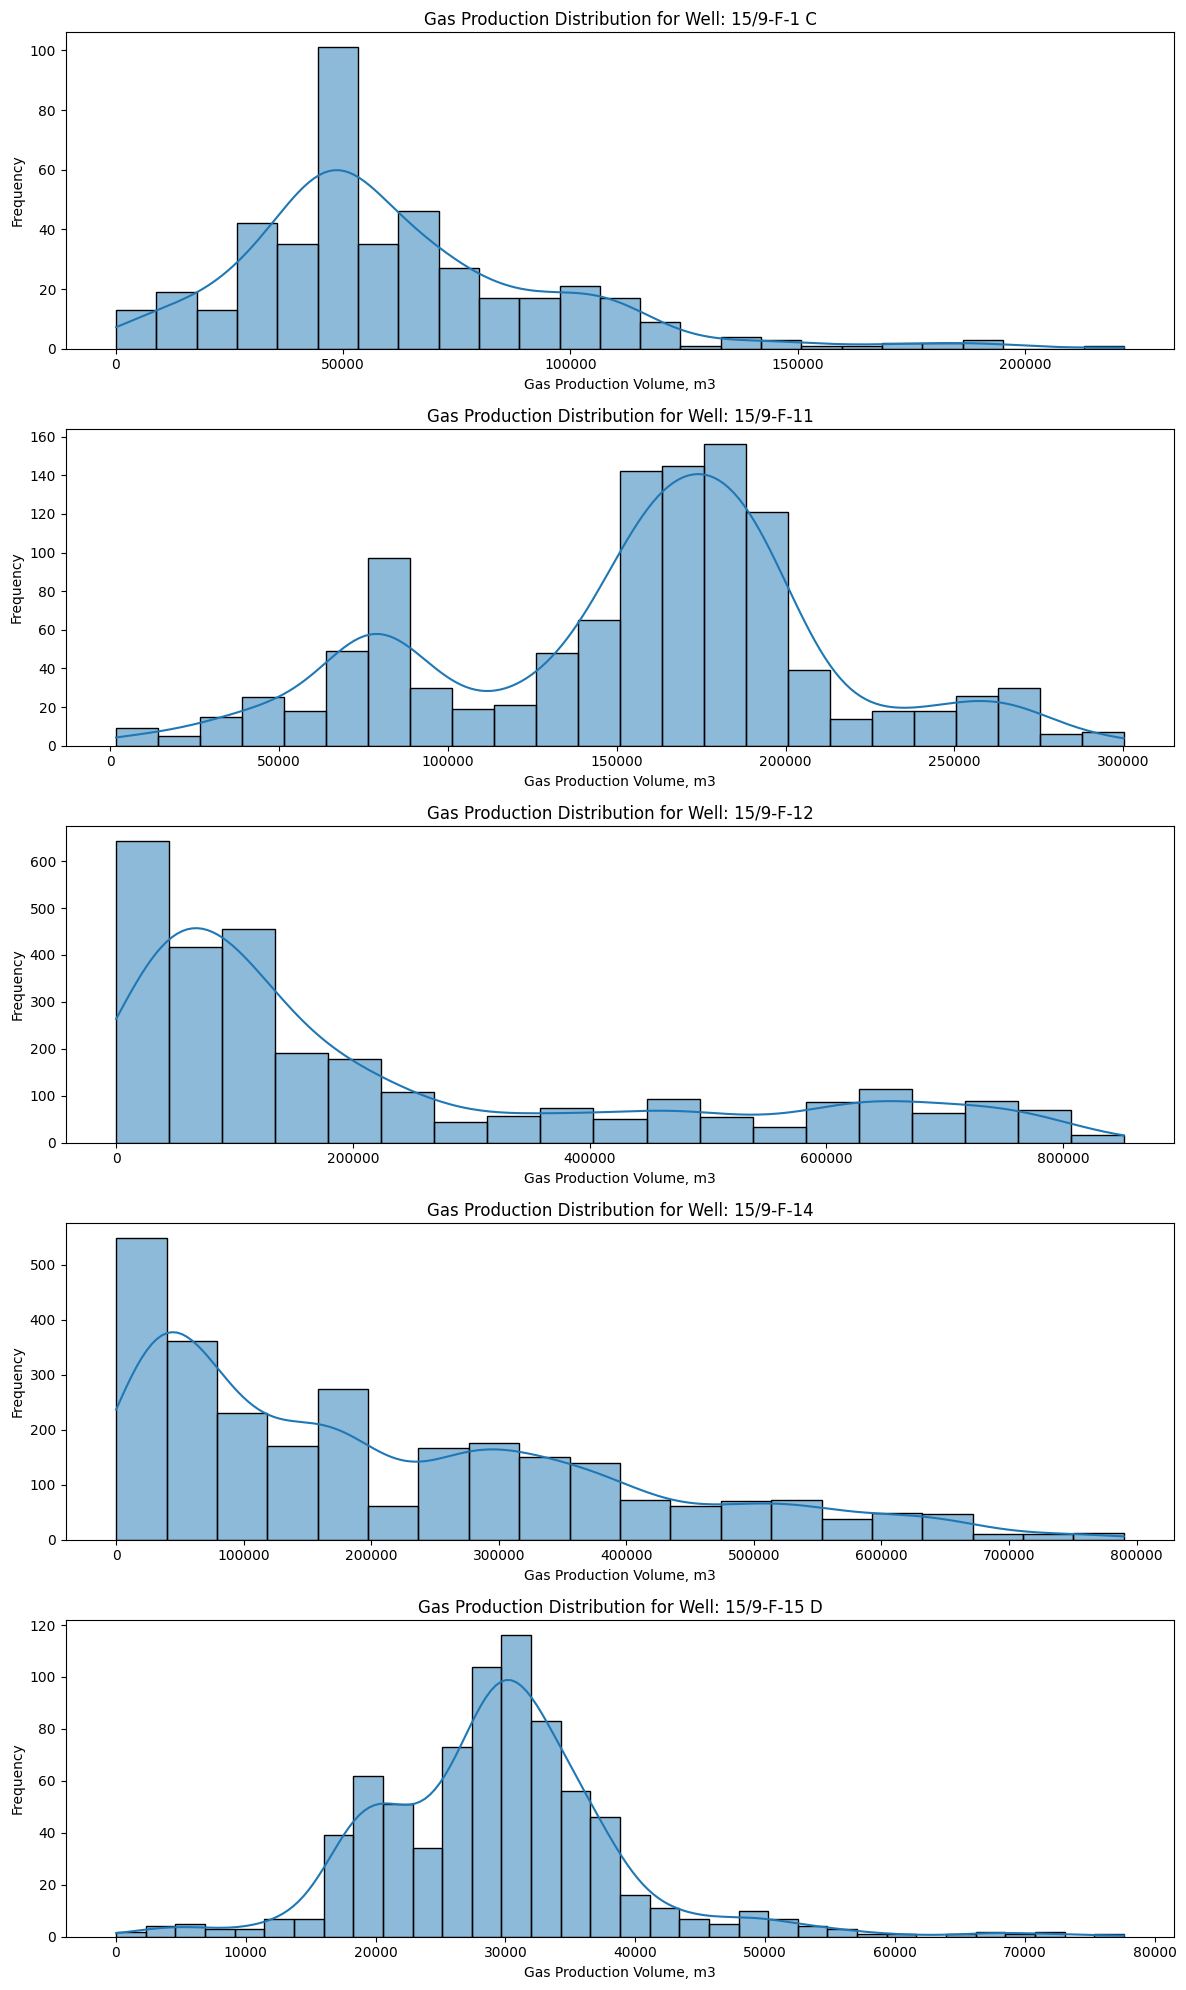

In [21]:
# Plot distributon of gas production in each well
fig, axes = plt.subplots(len(well_names), 1, figsize=(12, 4 * len(well_names)))

# Iterate through well names and plot each histogram
for i, well_name in enumerate(well_names):
    well_data = df[df['NPD_WELL_BORE_NAME'] == well_name]
    sns.histplot(well_data['BORE_GAS_VOL'], ax=axes[i], kde=True)
    axes[i].set_title(f'Gas Production Distribution for Well: {well_name}')
    axes[i].set_xlabel('Gas Production Volume, m3')
    axes[i].set_ylabel('Frequency')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

## Best Feature Combination Selection before Feature Engineering

In [22]:
df1 = df.copy()
df1

,DATEPRD,NPD_WELL_BORE_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,AVG_DP_TUBING,AVG_ANNULUS_PRESS,AVG_CHOKE_SIZE_P,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,BORE_WI_VOL,FLOW_KIND
0,2014-04-22,15/9-F-1 C,24.00,289.421,106.353,182.059,0.000,43.34345,107.362,37.939,78.935,631.0,90439.0,0.0,NaN,production
1,2014-04-23,15/9-F-1 C,24.00,270.240,107.644,171.053,NaN,47.16752,99.187,60.757,70.627,1166.0,165720.0,0.0,NaN,production
2,2014-04-24,15/9-F-1 C,24.00,262.843,107.869,168.242,NaN,47.73231,94.601,63.047,66.049,1550.0,221707.0,0.0,NaN,production
3,2014-04-25,15/9-F-1 C,24.00,255.527,107.971,165.539,NaN,48.53377,89.988,64.547,61.405,1249.0,178064.0,0.0,NaN,production
4,2014-04-26,15/9-F-1 C,24.00,247.199,108.052,162.422,NaN,49.84450,84.777,65.724,56.148,1346.0,192602.0,0.0,NaN,production
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7877,2016-07-02,15/9-F-15 D,24.00,194.984,106.518,179.171,21.318,31.57577,15.813,49.020,1.260,144.0,23201.0,204.0,NaN,production
7878,2016-07-03,15/9-F-15 D,24.00,194.978,106.516,179.204,21.105,31.54061,15.773,48.988,1.199,145.0,23068.0,203.0,NaN,production
7879,2016-07-04,15/9-F-15 D,24.00,194.317,106.521,178.615,21.354,31.52210,15.702,50.103,1.280,143.0,23060.0,204.0,NaN,production
7880,2016-07-05,15/9-F-15 D,24.00,195.207,106.507,179.599,20.630,31.52346,15.608,49.841,1.204,144.0,23090.0,203.0,NaN,production


In [23]:
# Fill missing values using the foward fill method
df1 = df1.ffill()

In [24]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7882 entries, 0 to 7881
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   DATEPRD                   7882 non-null   datetime64[ns]
 1   NPD_WELL_BORE_NAME        7882 non-null   object        
 2   ON_STREAM_HRS             7882 non-null   float64       
 3   AVG_DOWNHOLE_PRESSURE     7882 non-null   float64       
 4   AVG_DOWNHOLE_TEMPERATURE  7882 non-null   float64       
 5   AVG_DP_TUBING             7882 non-null   float64       
 6   AVG_ANNULUS_PRESS         7882 non-null   float64       
 7   AVG_CHOKE_SIZE_P          7882 non-null   float64       
 8   AVG_WHP_P                 7882 non-null   float64       
 9   AVG_WHT_P                 7882 non-null   float64       
 10  DP_CHOKE_SIZE             7882 non-null   float64       
 11  BORE_OIL_VOL              7882 non-null   float64       
 12  BORE_GAS_VOL        

In [25]:
df1.drop(columns=['ON_STREAM_HRS', 'BORE_OIL_VOL', 'BORE_WAT_VOL',
       'BORE_WI_VOL', 'FLOW_KIND'], inplace=True)

In [26]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7882 entries, 0 to 7881
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   DATEPRD                   7882 non-null   datetime64[ns]
 1   NPD_WELL_BORE_NAME        7882 non-null   object        
 2   AVG_DOWNHOLE_PRESSURE     7882 non-null   float64       
 3   AVG_DOWNHOLE_TEMPERATURE  7882 non-null   float64       
 4   AVG_DP_TUBING             7882 non-null   float64       
 5   AVG_ANNULUS_PRESS         7882 non-null   float64       
 6   AVG_CHOKE_SIZE_P          7882 non-null   float64       
 7   AVG_WHP_P                 7882 non-null   float64       
 8   AVG_WHT_P                 7882 non-null   float64       
 9   DP_CHOKE_SIZE             7882 non-null   float64       
 10  BORE_GAS_VOL              7882 non-null   float64       
dtypes: datetime64[ns](1), float64(9), object(1)
memory usage: 677.5+ KB


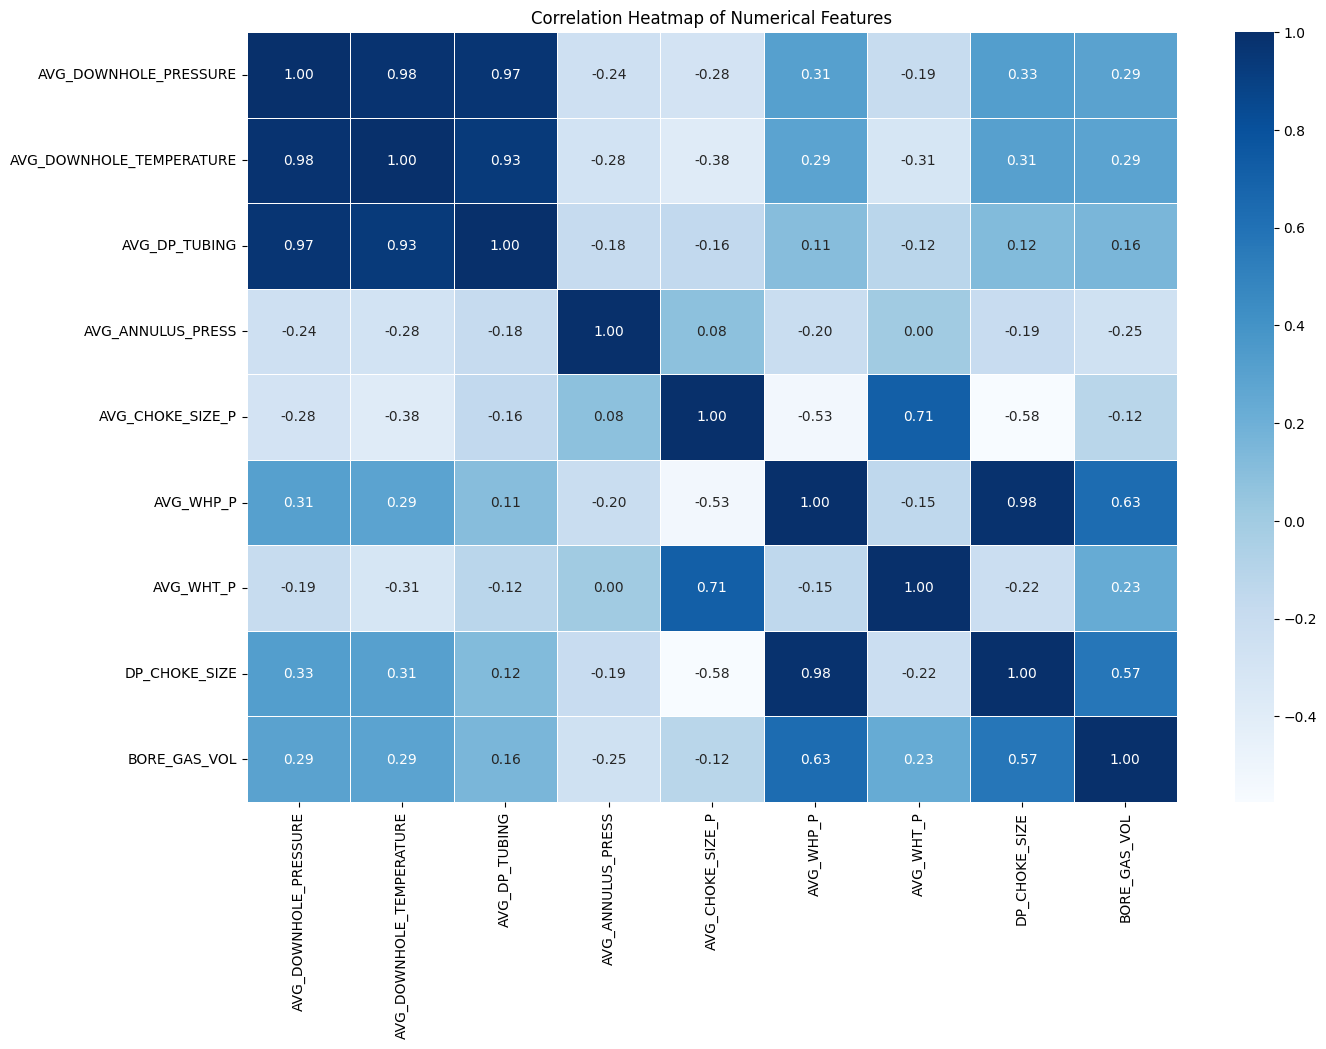

In [27]:
# Exclude non-numerical columns for correlation calculation
numerical_df = df1.select_dtypes(include=np.number)

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Plotting the heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [28]:
# Scale data
scaler = MinMaxScaler()

# Select the columns you want to scale
columns_to_scale = ['AVG_DOWNHOLE_PRESSURE',
       'AVG_DOWNHOLE_TEMPERATURE', 'AVG_DP_TUBING', 'AVG_ANNULUS_PRESS',
       'AVG_CHOKE_SIZE_P', 'AVG_WHP_P', 'AVG_WHT_P', 'DP_CHOKE_SIZE']

scaler.fit(df1[columns_to_scale])

# Transform your data
scaled_data = scaler.transform(df1[columns_to_scale])

# Replace the original columns with the scaled data
df1[columns_to_scale] = scaled_data
display(df1.head())

,DATEPRD,NPD_WELL_BORE_NAME,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,AVG_DP_TUBING,AVG_ANNULUS_PRESS,AVG_CHOKE_SIZE_P,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_GAS_VOL
0,2014-04-22,15/9-F-1 C,0.919445,0.980194,0.702694,0.0,0.431575,0.888104,0.405721,0.744424,90439.0
1,2014-04-23,15/9-F-1 C,0.858510,0.992092,0.660215,0.0,0.469942,0.820480,0.649738,0.666073,165720.0
2,2014-04-24,15/9-F-1 C,0.835011,0.994166,0.649365,0.0,0.475608,0.782544,0.674227,0.622898,221707.0
3,2014-04-25,15/9-F-1 C,0.811769,0.995106,0.638932,0.0,0.483649,0.744385,0.690268,0.579101,178064.0
4,2014-04-26,15/9-F-1 C,0.785312,0.995853,0.626901,0.0,0.496799,0.701280,0.702855,0.529523,192602.0


In [29]:
# Separate into features and target
target= 'BORE_GAS_VOL'
X = df1[['AVG_DOWNHOLE_PRESSURE',
       'AVG_DOWNHOLE_TEMPERATURE', 'AVG_DP_TUBING', 'AVG_ANNULUS_PRESS',
       'AVG_CHOKE_SIZE_P', 'AVG_WHP_P', 'AVG_WHT_P', 'DP_CHOKE_SIZE']]
y = df1[target]

# Split the dataset into 70:30
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size = 0.30, shuffle=False, random_state=42)
print (y.shape, X.shape, y_train.shape, X_train.shape)

(7882,) (7882, 8) (5517,) (5517, 8)


The initial code below evaluated the total 255 subsets from the 8 features. It was observed that features subsets with a size of four were more important. Hence, the present code has been modified to evaluate all feature subsets of size four (that is, 70 feature subsets) for the sake of efficiency.

In [ ]:
# Get top feature combination of size 4 that yield highest model performance
# Define all features
all_features = ['AVG_DOWNHOLE_PRESSURE',
       'AVG_DOWNHOLE_TEMPERATURE', 'AVG_DP_TUBING', 'AVG_ANNULUS_PRESS',
       'AVG_CHOKE_SIZE_P', 'AVG_WHP_P', 'AVG_WHT_P', 'DP_CHOKE_SIZE']

# Create a list to store results
results_list = []

# Iterate through all possible feature combinations of size 4
for i in range(4, 5):
    for feature_subset in itertools.combinations(all_features, i):
        # Extract data for the current feature subset
        X_train_subset = X_train[list(feature_subset)]
        X_test_subset = X_test[list(feature_subset)]

        # Create and train the Random Forest model
        rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
        rf_model.fit(X_train_subset, y_train)

        # Make predictions on the test set
        y_pred = rf_model.predict(X_test_subset)

        # Evaluate the model
        mse = mean_squared_error(y_test, y_pred)
        rmse = mse**0.5
        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        mape = mean_absolute_percentage_error(y_test, y_pred)

        # Append results to the list
        results_list.append([feature_subset, mse, rmse, r2, mae, mape])

# Create a pandas DataFrame from the results list
results_df = pd.DataFrame(results_list, columns=['Feature Subset', 'MSE', 'RMSE', 'R-squared', 'MAE', 'MAPE'])

# Sort the DataFrame by MAE in ascending order (best MAE first)
results_df = results_df.sort_values(by=['R-squared'])

# Display the table
display(results_df)

The best feature combination is ['AVG_DOWNHOLE_PRESSURE', 'AVG_CHOKE_SIZE_P', 'AVG_WHP_P', 'AVG_WHT_P'] with r2 of 0.676 and MAE of 0.032.

In [ ]:
# save results as a CSV file
results_df.to_csv('/content/drive/MyDrive/Datasets/random_forest_combined_wells_feature_evaluation.csv', index=False)

## Apply Feature Engineering (Differencing, Lagging, and Log transform) to Best Feature Combination

## 1. Lagging

In [31]:
df2 = df1.copy()
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7882 entries, 0 to 7881
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   DATEPRD                   7882 non-null   datetime64[ns]
 1   NPD_WELL_BORE_NAME        7882 non-null   object        
 2   AVG_DOWNHOLE_PRESSURE     7882 non-null   float64       
 3   AVG_DOWNHOLE_TEMPERATURE  7882 non-null   float64       
 4   AVG_DP_TUBING             7882 non-null   float64       
 5   AVG_ANNULUS_PRESS         7882 non-null   float64       
 6   AVG_CHOKE_SIZE_P          7882 non-null   float64       
 7   AVG_WHP_P                 7882 non-null   float64       
 8   AVG_WHT_P                 7882 non-null   float64       
 9   DP_CHOKE_SIZE             7882 non-null   float64       
 10  BORE_GAS_VOL              7882 non-null   float64       
dtypes: datetime64[ns](1), float64(9), object(1)
memory usage: 677.5+ KB


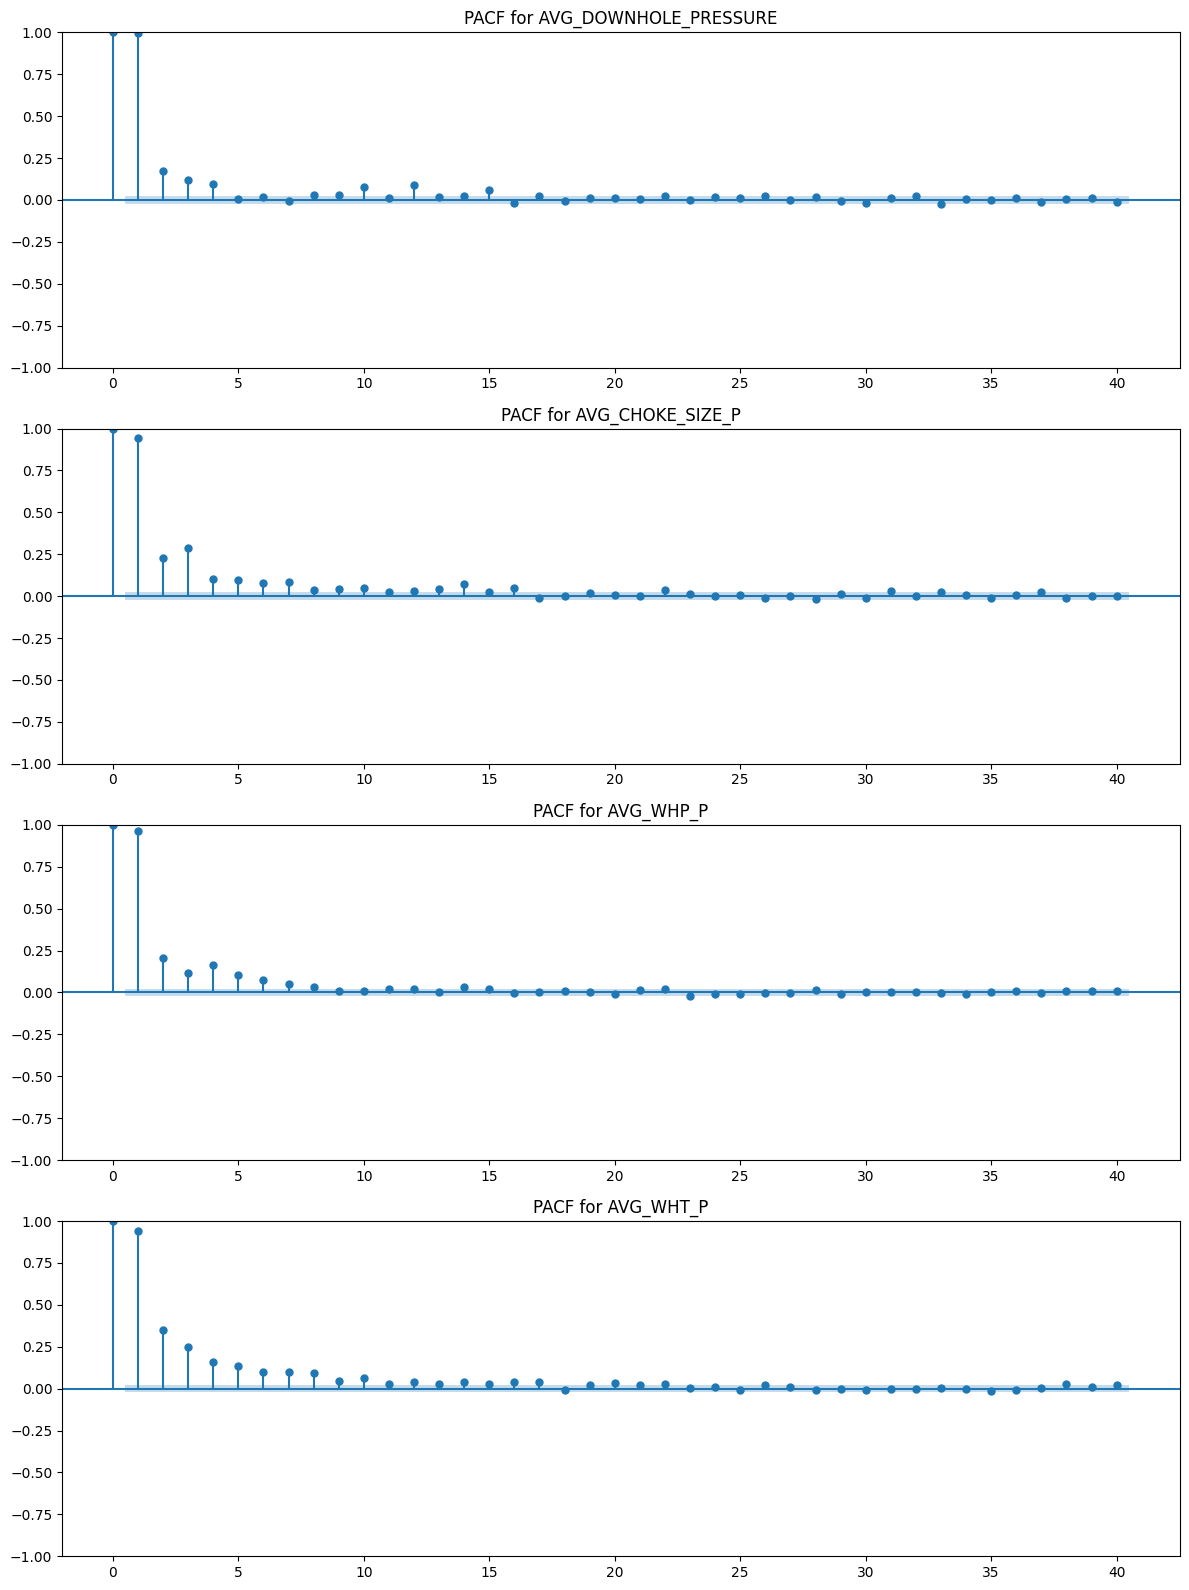

In [32]:
# Create PACF plots
# List of variables to plot
variables = ['AVG_DOWNHOLE_PRESSURE', 'AVG_CHOKE_SIZE_P', 'AVG_WHP_P', 'AVG_WHT_P']

# Create subplots
fig, axes = plt.subplots(len(variables), 1, figsize=(12, 4 * len(variables)))

# Iterate through variables and plot PACF
for i, var in enumerate(variables):
    sm.graphics.tsa.plot_pacf(df2[var].dropna(), lags=40, ax=axes[i], title=f'PACF for {var}')

plt.tight_layout()
plt.show()

In [33]:
# Apply Lagging using a lag of 3
columns_to_engineer = ['AVG_DOWNHOLE_PRESSURE', 'AVG_CHOKE_SIZE_P', 'AVG_WHP_P', 'AVG_WHT_P']

for column in columns_to_engineer:
  df2[column + '_lagged'] = df2[column].shift(3)

# Drop the first row with NaN values
df2 = df2.dropna()
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7879 entries, 3 to 7881
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   DATEPRD                       7879 non-null   datetime64[ns]
 1   NPD_WELL_BORE_NAME            7879 non-null   object        
 2   AVG_DOWNHOLE_PRESSURE         7879 non-null   float64       
 3   AVG_DOWNHOLE_TEMPERATURE      7879 non-null   float64       
 4   AVG_DP_TUBING                 7879 non-null   float64       
 5   AVG_ANNULUS_PRESS             7879 non-null   float64       
 6   AVG_CHOKE_SIZE_P              7879 non-null   float64       
 7   AVG_WHP_P                     7879 non-null   float64       
 8   AVG_WHT_P                     7879 non-null   float64       
 9   DP_CHOKE_SIZE                 7879 non-null   float64       
 10  BORE_GAS_VOL                  7879 non-null   float64       
 11  AVG_DOWNHOLE_PRESSURE_lagged  7879 

## 2. Differencing

In [34]:
# Apply diferencing with a lag of 3
for column in columns_to_engineer:
    df2[column + '_diff'] = (df2[column] - df2[column].shift(3)).abs()

# Drop the first row (NaN) after differencing
df2 = df2.dropna()
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7876 entries, 6 to 7881
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   DATEPRD                       7876 non-null   datetime64[ns]
 1   NPD_WELL_BORE_NAME            7876 non-null   object        
 2   AVG_DOWNHOLE_PRESSURE         7876 non-null   float64       
 3   AVG_DOWNHOLE_TEMPERATURE      7876 non-null   float64       
 4   AVG_DP_TUBING                 7876 non-null   float64       
 5   AVG_ANNULUS_PRESS             7876 non-null   float64       
 6   AVG_CHOKE_SIZE_P              7876 non-null   float64       
 7   AVG_WHP_P                     7876 non-null   float64       
 8   AVG_WHT_P                     7876 non-null   float64       
 9   DP_CHOKE_SIZE                 7876 non-null   float64       
 10  BORE_GAS_VOL                  7876 non-null   float64       
 11  AVG_DOWNHOLE_PRESSURE_lagged  7876 

## 3. Log Transform

In [35]:
# Apply log transformation
for column in columns_to_engineer:
  df2[column + '_log'] = np.log1p(df2[column])

df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7876 entries, 6 to 7881
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   DATEPRD                       7876 non-null   datetime64[ns]
 1   NPD_WELL_BORE_NAME            7876 non-null   object        
 2   AVG_DOWNHOLE_PRESSURE         7876 non-null   float64       
 3   AVG_DOWNHOLE_TEMPERATURE      7876 non-null   float64       
 4   AVG_DP_TUBING                 7876 non-null   float64       
 5   AVG_ANNULUS_PRESS             7876 non-null   float64       
 6   AVG_CHOKE_SIZE_P              7876 non-null   float64       
 7   AVG_WHP_P                     7876 non-null   float64       
 8   AVG_WHT_P                     7876 non-null   float64       
 9   DP_CHOKE_SIZE                 7876 non-null   float64       
 10  BORE_GAS_VOL                  7876 non-null   float64       
 11  AVG_DOWNHOLE_PRESSURE_lagged  7876 

In [36]:
# Reset the index
df2 = df2.reset_index(drop=True)
df2.head()

,DATEPRD,NPD_WELL_BORE_NAME,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,AVG_DP_TUBING,AVG_ANNULUS_PRESS,AVG_CHOKE_SIZE_P,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,...,AVG_WHP_P_lagged,AVG_WHT_P_lagged,AVG_DOWNHOLE_PRESSURE_diff,AVG_CHOKE_SIZE_P_diff,AVG_WHP_P_diff,AVG_WHT_P_diff,AVG_DOWNHOLE_PRESSURE_log,AVG_CHOKE_SIZE_P_log,AVG_WHP_P_log,AVG_WHT_P_log
0,2014-04-28,15/9-F-1 C,0.746625,0.995760,0.608610,0.0,0.505742,0.639744,0.725569,0.459358,...,0.744385,0.690268,0.065144,0.022093,0.104641,0.035301,0.557685,0.409286,0.494540,0.545557
1,2014-04-29,15/9-F-1 C,0.739391,0.995263,0.605183,0.0,0.499502,0.628254,0.702674,0.446796,...,0.701280,0.702855,0.045921,0.002703,0.073026,0.000182,0.553535,0.405133,0.487508,0.532200
2,2014-04-30,15/9-F-1 C,0.741151,0.994387,0.606665,0.0,0.487592,0.629652,0.671543,0.449012,...,0.668688,0.715795,0.023629,0.013747,0.039036,0.044252,0.554546,0.397159,0.488366,0.513747
3,2014-05-01,15/9-F-1 C,0.734133,0.994240,0.603654,0.0,0.487711,0.617840,0.667062,0.435667,...,0.639744,0.725569,0.012491,0.018031,0.021904,0.058507,0.550508,0.397239,0.481092,0.511063
4,2014-05-02,15/9-F-1 C,0.735182,0.993687,0.604778,0.0,0.481341,0.618162,0.649631,0.435234,...,0.628254,0.702674,0.004209,0.018162,0.010092,0.053042,0.551112,0.392948,0.481291,0.500552


## Selection of Best Feature Combination after Feature Engineering

In [37]:
# Separate into features and target
target= 'BORE_GAS_VOL'
X = df2[['AVG_DOWNHOLE_PRESSURE', 'AVG_CHOKE_SIZE_P', 'AVG_WHP_P', 'AVG_WHT_P', 'AVG_DOWNHOLE_PRESSURE_lagged',
       'AVG_CHOKE_SIZE_P_lagged', 'AVG_WHP_P_lagged', 'AVG_WHT_P_lagged',
       'AVG_DOWNHOLE_PRESSURE_diff', 'AVG_CHOKE_SIZE_P_diff', 'AVG_WHP_P_diff',
       'AVG_WHT_P_diff', 'AVG_DOWNHOLE_PRESSURE_log', 'AVG_CHOKE_SIZE_P_log',
       'AVG_WHP_P_log', 'AVG_WHT_P_log']]
y = df2[target]

# Split the dataset into 65:35 (selected after testing different split ratios)
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size = 0.35, shuffle=False, random_state=42)
print (y_test.shape, X_test.shape, y_train.shape, X_train.shape)

(2757,) (2757, 16) (5119,) (5119, 16)


The initial code below evaluated the total 65,535 subsets from the 16 features. It was observed that features subsets with a size of five were more important. Hence, the present code has been modified to evaluate all feature subsets of size five (that is, 4368 feature subsets) for the sake of efficiency.

In [ ]:
# Get top feature combination of size 5 that yield highest model performance
# Define all features
all_features = ['AVG_DOWNHOLE_PRESSURE', 'AVG_CHOKE_SIZE_P', 'AVG_WHP_P', 'AVG_WHT_P', 'AVG_DOWNHOLE_PRESSURE_lagged',
       'AVG_CHOKE_SIZE_P_lagged', 'AVG_WHP_P_lagged', 'AVG_WHT_P_lagged',
       'AVG_DOWNHOLE_PRESSURE_diff', 'AVG_CHOKE_SIZE_P_diff', 'AVG_WHP_P_diff',
       'AVG_WHT_P_diff', 'AVG_DOWNHOLE_PRESSURE_log', 'AVG_CHOKE_SIZE_P_log',
       'AVG_WHP_P_log', 'AVG_WHT_P_log']

# Create a list to store results
results_list = []

# Iterate through all possible feature combinations of size 5
for i in range(5, 6):
    for feature_subset in itertools.combinations(all_features, i):
        # Extract data for the current feature subset
        X_train_subset = X_train[list(feature_subset)]
        X_test_subset = X_test[list(feature_subset)]

        # Create and train the Random Forest model
        rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
        rf_model.fit(X_train_subset, y_train)

        # Make predictions on the test set
        y_pred = rf_model.predict(X_test_subset)

        # Evaluate the model
        mse = mean_squared_error(y_test, y_pred)
        rmse = mse**0.5
        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        mape = mean_absolute_percentage_error(y_test, y_pred)

        # Append results to the list
        results_list.append([feature_subset, mse, rmse, r2, mae, mape])

# Create a pandas DataFrame from the results list
results_df = pd.DataFrame(results_list, columns=['Feature Subset', 'MSE', 'RMSE', 'R-squared', 'MAE', 'MAPE'])

# Sort the DataFrame by MAE in ascending order (best MAE first)
results_df = results_df.sort_values(by=['R-squared'])

# Display the table
display(results_df)

,Feature Subset,MSE,RMSE,R-squared,MAE,MAPE
990,"(AVG_DOWNHOLE_PRESSURE, AVG_DOWNHOLE_PRESSURE_...",8.001300e+10,282865.693934,-7.528869,240800.830873,8.864718
1015,"(AVG_DOWNHOLE_PRESSURE, AVG_DOWNHOLE_PRESSURE_...",7.296183e+10,270114.467641,-6.777260,227090.549641,8.555451
985,"(AVG_DOWNHOLE_PRESSURE, AVG_DOWNHOLE_PRESSURE_...",7.065803e+10,265815.772733,-6.531689,224730.021973,8.340478
3851,"(AVG_DOWNHOLE_PRESSURE_lagged, AVG_DOWNHOLE_PR...",7.047784e+10,265476.634142,-6.512483,224652.331685,8.464325
1310,"(AVG_DOWNHOLE_PRESSURE, AVG_DOWNHOLE_PRESSURE_...",7.045050e+10,265425.137656,-6.509569,224571.875762,8.254210
...,...,...,...,...,...,...
41,"(AVG_DOWNHOLE_PRESSURE, AVG_CHOKE_SIZE_P, AVG_...",1.628707e+09,40357.238142,0.826390,27364.422231,1.271558
2,"(AVG_DOWNHOLE_PRESSURE, AVG_CHOKE_SIZE_P, AVG_...",1.627909e+09,40347.350094,0.826475,27546.410860,1.223329
279,"(AVG_DOWNHOLE_PRESSURE, AVG_CHOKE_SIZE_P, AVG_...",1.626285e+09,40327.227775,0.826648,27450.605322,1.227008
1782,"(AVG_CHOKE_SIZE_P, AVG_WHT_P, AVG_WHP_P_lagged...",1.620900e+09,40260.398309,0.827223,27232.221349,1.196450


After feature engineering, the best feature subset is ['AVG_CHOKE_SIZE_P', 'AVG_WHP_P', 'AVG_WHP_P_lagged', 'AVG_DOWNHOLE_PRESSURE_log', 'AVG_WHT_P_log'] with r2 score of 0.828.

In [ ]:
# save results as a CSV file
results_df.to_csv('/content/drive/MyDrive/Datasets/random_forest_combined_wells_lagged_3_feature_evaluation(size 5).csv', index=False)

## Train Random Forest and LSTM with the final feature subset ['AVG_CHOKE_SIZE_P', 'AVG_WHP_P', 'AVG_WHP_P_lagged', 'AVG_DOWNHOLE_PRESSURE_log', 'AVG_WHT_P_log']

In [38]:
# Set the date column as index
df2 = df2.set_index('DATEPRD')
df2

,NPD_WELL_BORE_NAME,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,AVG_DP_TUBING,AVG_ANNULUS_PRESS,AVG_CHOKE_SIZE_P,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_GAS_VOL,...,AVG_WHP_P_lagged,AVG_WHT_P_lagged,AVG_DOWNHOLE_PRESSURE_diff,AVG_CHOKE_SIZE_P_diff,AVG_WHP_P_diff,AVG_WHT_P_diff,AVG_DOWNHOLE_PRESSURE_log,AVG_CHOKE_SIZE_P_log,AVG_WHP_P_log,AVG_WHT_P_log
DATEPRD,,,,,,,,,,,,,,,,,,,,,
2014-04-28,15/9-F-1 C,0.746625,0.995760,0.608610,0.000000,0.505742,0.639744,0.725569,0.459358,192900.0,...,0.744385,0.690268,0.065144,0.022093,0.104641,0.035301,0.557685,0.409286,0.494540,0.545557
2014-04-29,15/9-F-1 C,0.739391,0.995263,0.605183,0.000000,0.499502,0.628254,0.702674,0.446796,184900.0,...,0.701280,0.702855,0.045921,0.002703,0.073026,0.000182,0.553535,0.405133,0.487508,0.532200
2014-04-30,15/9-F-1 C,0.741151,0.994387,0.606665,0.000000,0.487592,0.629652,0.671543,0.449012,177108.0,...,0.668688,0.715795,0.023629,0.013747,0.039036,0.044252,0.554546,0.397159,0.488366,0.513747
2014-05-01,15/9-F-1 C,0.734133,0.994240,0.603654,0.000000,0.487711,0.617840,0.667062,0.435667,174609.0,...,0.639744,0.725569,0.012491,0.018031,0.021904,0.058507,0.550508,0.397239,0.481092,0.511063
2014-05-02,15/9-F-1 C,0.735182,0.993687,0.604778,0.000000,0.481341,0.618162,0.649631,0.435234,154871.0,...,0.628254,0.702674,0.004209,0.018162,0.010092,0.053042,0.551112,0.392948,0.481291,0.500552
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-07-02,15/9-F-15 D,0.619433,0.981715,0.691548,0.710127,0.313513,0.130806,0.524222,0.011883,23201.0,...,0.139508,0.489969,0.006900,0.036160,0.008702,0.034253,0.482076,0.272705,0.122931,0.421484
2016-07-03,15/9-F-15 D,0.619414,0.981696,0.691675,0.703031,0.313160,0.130475,0.523880,0.011308,23068.0,...,0.139119,0.511710,0.005188,0.032882,0.008644,0.012170,0.482065,0.272436,0.122638,0.421260
2016-07-04,15/9-F-15 D,0.617314,0.981742,0.689402,0.711326,0.312974,0.129888,0.535804,0.012071,23060.0,...,0.131153,0.525217,0.003224,0.004652,0.001266,0.010587,0.480767,0.272295,0.122118,0.429054


In [39]:
# Separate features (final feature subset) and target
target= 'BORE_GAS_VOL'
X = df2[['AVG_CHOKE_SIZE_P', 'AVG_WHP_P', 'AVG_WHP_P_lagged', 'AVG_DOWNHOLE_PRESSURE_log', 'AVG_WHT_P_log']]
y = df2[target]

# Split into ratio 65:35
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size = 0.35, shuffle=False, random_state=42)
print (y_test.shape, X_test.shape, y_train.shape, X_train.shape)

(2757,) (2757, 5) (5119,) (5119, 5)


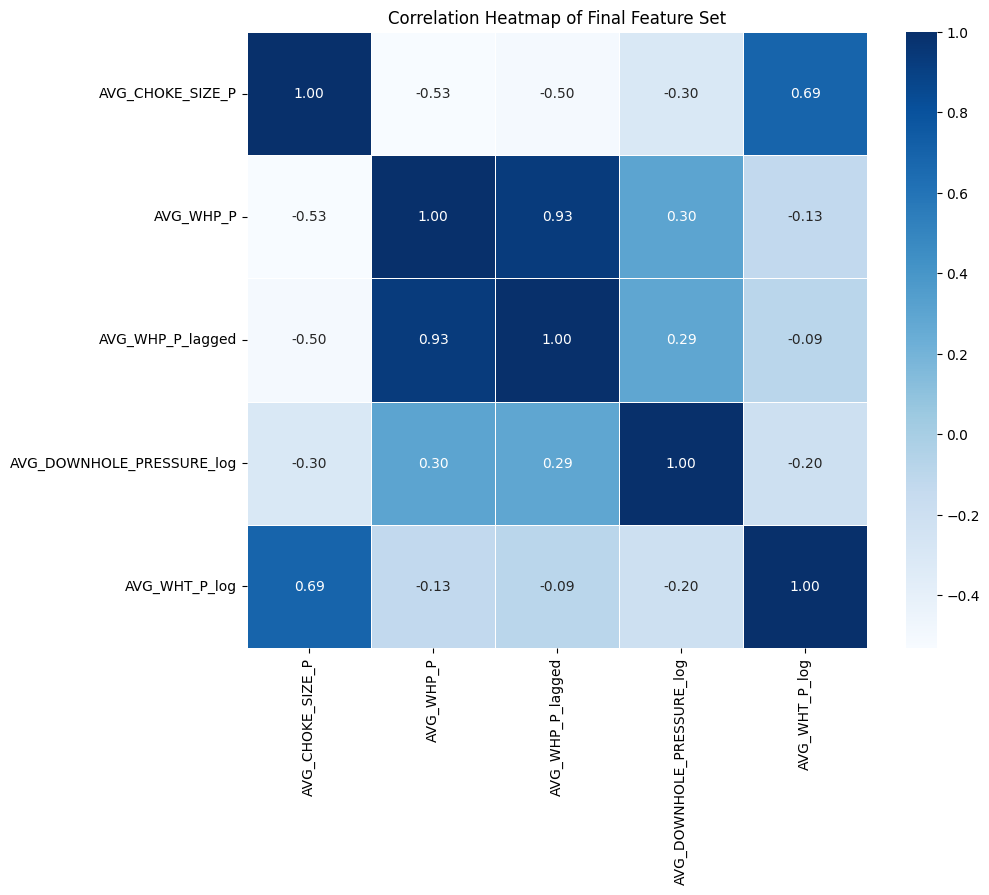

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix for X
correlation_matrix_X = X.corr()

# Plotting the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_X, annot=True, cmap='Blues', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Final Feature Set')
plt.show()

In [41]:
print(y_train.head(10))

DATEPRD
2014-04-28    192900.0
2014-04-29    184900.0
2014-04-30    177108.0
2014-05-01    174609.0
2014-05-02    154871.0
2014-05-03    147930.0
2014-05-04    139378.0
2014-05-05    136980.0
2014-05-06    144950.0
2014-05-07    135000.0
Name: BORE_GAS_VOL, dtype: float64


In [42]:
print(y_test.head(10))

DATEPRD
2010-09-01    217223.0
2010-09-02    453753.0
2010-09-03    332337.0
2010-09-04    338531.0
2010-09-05    331445.0
2010-09-06    316423.0
2010-09-07    333181.0
2010-09-08    334409.0
2010-09-09    342164.0
2010-09-10    357524.0
Name: BORE_GAS_VOL, dtype: float64


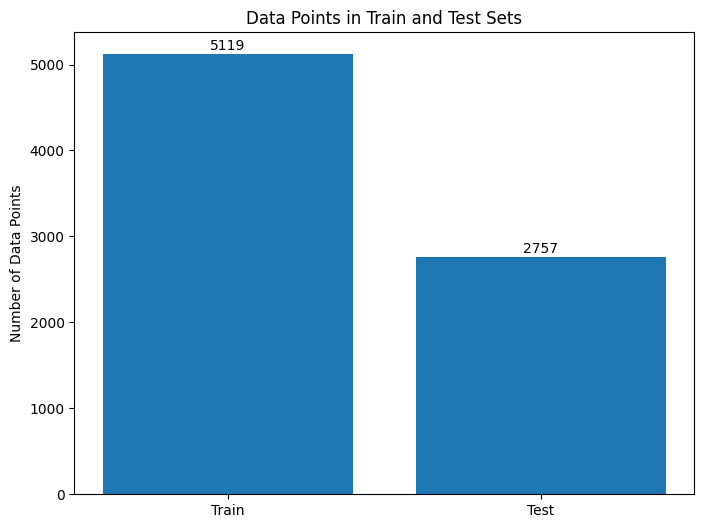

In [43]:
# Plot number of data points in training and test sets
train_size = len(X_train)
test_size = len(X_test)

# Create a bar plot
plt.figure(figsize=(8, 6))
plt.bar(['Train', 'Test'], [train_size, test_size])
plt.ylabel('Number of Data Points')
plt.title('Data Points in Train and Test Sets')

# Add labels to the bars
plt.text(0, train_size + 10, train_size, ha='center', va='bottom')
plt.text(1, test_size + 10, test_size, ha='center', va='bottom')

plt.show()

## 1. Random Forest Model

In [44]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions on the test set
rf_pred = rf_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, rf_pred)
rmse = mse**0.5
r2 = r2_score(y_test, rf_pred)
mae = mean_absolute_error(y_test, rf_pred)
mape = mean_absolute_percentage_error(y_test, rf_pred)

print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R-squared: {r2}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Absolute Percentage Error (MAPE): {mape}%")

Mean Squared Error: 1614462006.5992732
Root Mean Squared Error: 40180.36842289121
R-squared: 0.8279087702415318
Mean Absolute Error (MAE): 27227.740382057793
Mean Absolute Percentage Error (MAPE): 1.2672465326307965%


## 2. LSTM Model

In [ ]:
# Reshape input to be [samples, time steps, features] which is required for LSTM
X_train_lstm = X_train.values.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test_lstm = X_test.values.reshape(X_test.shape[0], 1, X_test.shape[1])

### LSTM Hyperparameter Tuning using Bayesian Optimization

In [ ]:
# Define the LSTM model
def create_model(num_layers=1, num_units=50, learning_rate=0.01):
    model = Sequential()
    for i in range(num_layers):
        # Return sequences for all layers except the last one
        return_sequences = i < num_layers - 1
        model.add(LSTM(num_units, activation='relu', input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]), return_sequences=return_sequences))
    # Output layer with 1 neuron for regression
    model.add(Dense(1))
    model.compile(loss='mse', optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate))
    return model

# Define the search space for hyperparameters
search_space = {
    'num_layers': Integer(1, 2),
    'num_units': Integer(32, 64),
    'learning_rate': Real(1e-3, 1e-2, prior='log-uniform'),
    'batch_size': Categorical([32, 64]),
    'epochs': Integer(20, 50)
}

# Create KerasRegressor wrapper for the model
keras_regressor = KerasRegressor(
    model=create_model,
    num_layers=1,
    num_units=50,
    learning_rate=0.01,
    verbose=0
)

# Create BayesSearchCV object
bayes_search = BayesSearchCV(
    estimator=keras_regressor,
    search_spaces=search_space,
    n_iter=50,
    cv=None,
    scoring='neg_mean_squared_error',
    random_state=42,
    verbose=2,
    n_jobs=-1
)

# Fit the model
bayes_search.fit(X_train_lstm, y_train)


# Print best hyperparameters
print("Best Hyperparameters:", bayes_search.best_params_)

best_model = bayes_search.best_estimator_
y_pred = best_model.predict(X_test_lstm)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared: {r2}")

In [ ]:
# Train LSTM with defined lookback
def create_dataset(dataset, look_back=12):
    """
    Creates a dataset with lookback for LSTM.

    Args:
        dataset: The original dataset (NumPy array or pandas DataFrame).
        look_back: The number of previous time steps to consider.

    Returns:
        X: The input features with lookback.
        Y: The target variable.
    """
    X, Y = [], []
    for i in range(len(dataset)-look_back-1):
        a = dataset[i:(i+look_back), :]
        X.append(a)
        Y.append(dataset[i + look_back, -1])
    return np.array(X), np.array(Y)


# Set the desired lookback value
look_back = 12

# Select features and target
target = 'BORE_GAS_VOL'
features = ['AVG_CHOKE_SIZE_P', 'AVG_WHP_P', 'AVG_WHP_P_lagged', 'AVG_DOWNHOLE_PRESSURE_log', 'AVG_WHT_P_log']
# Combine features and target
dataset = df2[features + [target]].values

# Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
dataset = scaler.fit_transform(dataset)

# Create the dataset with lookback
X, y = create_dataset(dataset, look_back)

# Split into train and test sets
X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(X, y, test_size=0.35, shuffle=False, random_state=42)


# Best hyperparameters
best_params = {
    'batch_size': 32,
    'epochs': 43,
    'learning_rate': 0.0017637852961221638,
    'num_layers': 2,
    'num_units': 51
}

# Define the LSTM model
model = Sequential()

# Add LSTM layers
for i in range(best_params['num_layers']):
    # Return sequences for all layers except the last one
    return_sequences = i < best_params['num_layers'] - 1
    model.add(LSTM(best_params['num_units'], activation='relu',
                   input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]),
                   return_sequences=return_sequences))

# Add output layer
model.add(Dense(1))

# Compile the model
optimizer = tf.keras.optimizers.Adam(learning_rate=best_params['learning_rate'])
model.compile(loss='mse', optimizer=optimizer)

# Train the model
model.fit(X_train_lstm, y_train_lstm, epochs=best_params['epochs'],
          batch_size=best_params['batch_size'], verbose=1)

Epoch 1/43
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0303
Epoch 2/43
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0078
Epoch 3/43
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0072
Epoch 4/43
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0064
Epoch 5/43
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0052
Epoch 6/43
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0050
Epoch 7/43
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0053
Epoch 8/43
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0051
Epoch 9/43
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0052
Epoch 10/43
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0048
Epoch 11/43
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0046
Epoch 12/43
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0044
Epoch 13/43
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0053
Epoch 14/43
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0046
Epoch 15/43
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s

In [ ]:
# Re-create the scaler used for LSTM to inverse transform the data
target_lstm = 'BORE_GAS_VOL'
features_lstm = ['AVG_CHOKE_SIZE_P', 'AVG_WHP_P', 'AVG_WHP_P_lagged', 'AVG_DOWNHOLE_PRESSURE_log', 'AVG_WHT_P_log']

# Create a temporary DataFrame for fitting the scaler, similar to how it was originally fitted
temp_df_for_scaler = df2[features_lstm + [target_lstm]].copy()
scaler_lstm = MinMaxScaler(feature_range=(0, 1))
scaler_lstm.fit(temp_df_for_scaler.values)

# Inverse transform y_test_lstm
dummy_y_test_scaled = np.zeros((len(y_test_lstm), len(features_lstm) + 1))
# Place scaled y_test into the target column
dummy_y_test_scaled[:, -1] = y_test_lstm
y_test_unscaled = scaler_lstm.inverse_transform(dummy_y_test_scaled)[:, -1]

# Make predictions on the test set
lstm_pred = model.predict(X_test_lstm)

# Inverse transform lstm_pred
dummy_lstm_pred_scaled = np.zeros((len(lstm_pred), len(features_lstm) + 1))
dummy_lstm_pred_scaled[:, -1] = lstm_pred.flatten()
lstm_pred_unscaled = scaler_lstm.inverse_transform(dummy_lstm_pred_scaled)[:, -1]

# Evaluate the model with unscaled values
mse_unscaled = mean_squared_error(y_test_unscaled, lstm_pred_unscaled)
rmse_unscaled = np.sqrt(mse_unscaled)
r2_unscaled = r2_score(y_test_unscaled, lstm_pred_unscaled)
mae_unscaled = mean_absolute_error(y_test_unscaled, lstm_pred_unscaled)
mape_unscaled = mean_absolute_percentage_error(y_test_unscaled, lstm_pred_unscaled)

print(f"Mean Squared Error (MSE): {mse_unscaled}")
print(f"Root Mean Squared Error (RMSE): {rmse_unscaled}")
print(f"R-squared: {r2_unscaled}")
print(f"Mean Absolute Error (MAE): {mae_unscaled}")
print(f"Mean Absolute Percentage Error (MAPE): {mape_unscaled}%")

87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Mean Squared Error (MSE): 809865947.0426823
Root Mean Squared Error (RMSE): 28458.143773666656
R-squared: 0.9131247754033562
Mean Absolute Error (MAE): 16176.520567710373
Mean Absolute Percentage Error (MAPE): 2.109256667748973%


In [ ]:
# Create a comparison table
comparison_table = pd.DataFrame({
    'Model': ['Random Forest', 'LSTM'],
    'R-squared': [r2, r2_unscaled],
    'MAE': [mae, mae_unscaled],
    'RMSE': [rmse, rmse_unscaled],
    'MAPE': [mape, mape_unscaled]
})
comparison_table

,Model,R-squared,MAE,RMSE,MAPE
0,Random Forest,0.827909,27227.740382,40180.368423,1.267247
1,LSTM,0.913125,16176.520568,28458.143774,2.109257


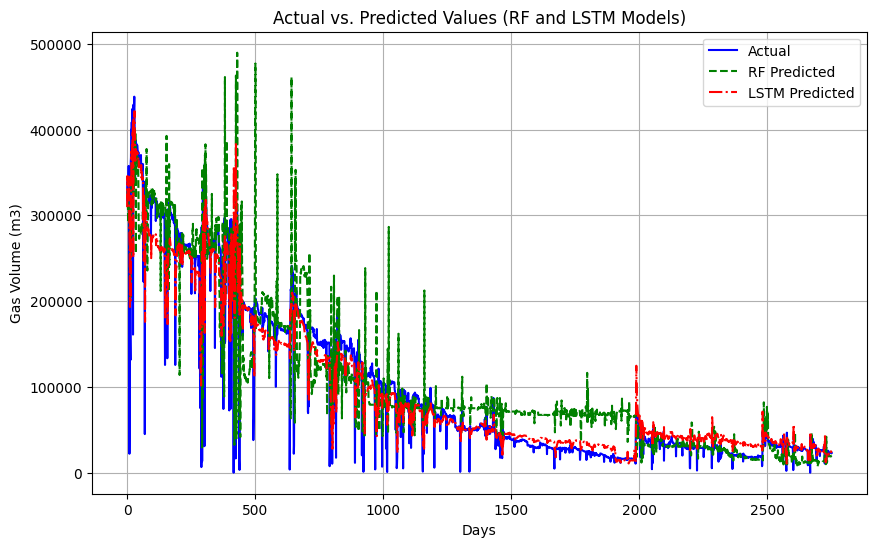

In [ ]:
# Plot actual vs predicted values
# Get the minimum length for consistent plotting among all three series
min_length_plot = min(len(y_test_unscaled), len(rf_pred), len(lstm_pred_unscaled))

# Truncate all arrays to min_length_plot
y_actual_truncated = y_test_unscaled[:min_length_plot]
rf_pred_truncated = rf_pred[:min_length_plot]
lstm_pred_truncated = lstm_pred_unscaled[:min_length_plot]

plt.figure(figsize=(10, 6))

# Plot actual values
plt.plot(np.arange(min_length_plot), y_actual_truncated, label='Actual', color='blue')

# Plot RF predictions
plt.plot(np.arange(min_length_plot), rf_pred_truncated, label='RF Predicted', color='green', linestyle='--')

# Plot LSTM predictions
plt.plot(np.arange(min_length_plot), lstm_pred_truncated, label='LSTM Predicted', color='red', linestyle='-.')

plt.xlabel('Days')
plt.ylabel('Gas Volume (m3)') # Updated label for unscaled data
plt.title('Actual vs. Predicted Values (RF and LSTM Models)')
plt.legend()
plt.grid(True)
plt.show()

## Results and Discussion

The results show that the LSTM model performs better overall in predicting gas production volumes. With an R² of 0.907, the LSTM explains about 90.7% of the variability in the production data, compared to 82.8% for the Random Forest model. In addition, the LSTM has lower MAE (19,359.99) and RMSE (29,382.71), indicating that its predictions are closer to the actual production values and that it makes fewer large errors. Since gas production is a time-dependent process influenced by reservoir depletion, pressure changes, and operational dynamics, the LSTM’s ability to capture temporal patterns likely contributes to its superior performance. However, the Random Forest model achieves a lower MAPE (1.27% compared to 2.09% for LSTM), meaning its average percentage error relative to actual production is smaller. This suggests that while LSTM reduces absolute deviations, Random Forest may provide slightly better proportional consistency in its predictions. In other words, Random Forest predictions may be relatively more stable when viewed as a percentage of actual production volumes.

In real-world applications, these differences have important implications. The lower MAE and RMSE of the LSTM model mean more accurate volume forecasts, which directly affect revenue estimation, budgeting, reserves evaluation, and long-term development planning. Even modest absolute prediction errors in a producing gas field can translate into significant financial differences. Furthermore, lower RMSE reduces the likelihood of extreme forecasting errors, which is critical for infrastructure sizing, compression planning, and strategic decision-making. On the other hand, the lower MAPE of the Random Forest model could be beneficial in operational contexts where proportional accuracy is more important than absolute precision, such as short-term production monitoring and optimization. Overall, for strategic forecasting and financial planning in the Volve field, the LSTM model appears more suitable due to its stronger explanatory power and lower absolute error, although Random Forest remains a competitive alternative depending on the operational objective.



## Conclusion

Accurate gas production forecasting is pivotal for optimizing reservoir management, operational efficiency, and economic planning in the oil and gas industry. This study addressed the limitations of conventional data-driven models by proposing a multi-well machine learning framework with operational data embedding that integrates operational parameters such as Average Downhole Pressure, Average Choke Size Percentage, Average Wellhead Pressure, and Average Wellhead Temperature with advanced algorithms to capture both temporal dynamics and reservoir physics. The key findings and contributions of this research are summarized as follows:
- Four operational parameters, namely 	Average Downhole Pressure, Average Choke Size Percentage, Average Wellhead Pressure, and Average Wellhead Temperature had the highest importance in forecasting gas production across multiple wells.
- Empirical evaluation of train-test splits revealed that a 65:35 ratio achieved the best balance between training sufficiency and generalizability (R² = 0.771 for RF), emphasizing the need for temporal coherence in time-series forecasting.
- Engineered features played significant roles in boosting the R2 score from 0.771 to 0.828, indicating the importance of feature engineering techniques in time series analysis.
- The Long Short-Term Memory (LSTM) neural network demonstrated significant advantages over Random Forest (RF), achieving a 9.54% improvement in R² (0.907 vs. 0.828) and a 28.89% reduction in Mean Absolute Error (19359.999m3 vs. 27227.740m3). This underscores LSTM’s ability to model complex temporal dependencies inherent in gas production data, such as delayed effects of operational adjustments and reservoir depletion trends.